# Semiconductor Quality Control — Wafer Defect Prediction

**Objective:** Predict whether a semiconductor wafer is defective based on fabrication process sensor readings.

**Dataset:** 4,219 wafers | 16 columns | Binary target — `Defect` (0 = Good, 1 = Defective)

**Domain Context:**
- Defect rate is ~14.6% — the dataset is **imbalanced**
- In semiconductor manufacturing, **missing a defect (False Negative) is far more costly** than a false alarm
- A missed defect can propagate through downstream processes, ruining entire wafer batches

## Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


##  Load Dataset

In [ ]:
df = pd.read_csv('semiconductor_quality_control.csv')
print('Dataset loaded — Shape:', df.shape)
df.head()

Dataset loaded — Shape: (4219, 16)


,Process_ID,Timestamp,Tool_Type,Wafer_ID,Chamber_Temperature,Gas_Flow_Rate,RF_Power,Etch_Depth,Rotation_Speed,Vacuum_Pressure,Stage_Alignment_Error,Vibration_Level,UV_Exposure_Intensity,Particle_Count,Defect,Join_Status
0,P1413,01-07-2025 05:12,Lithography,WAF58120,74.077728,56.527432,324.281923,554.358076,1397.936121,0.549974,2.147302,0.009007,128.419361,118,0,Joining
1,P1687,01-07-2025 03:54,Deposition,WAF31094,74.341499,39.350802,364.527083,493.382895,1433.488274,0.407351,2.970405,0.007927,109.449848,525,0,Joining
2,P1802,01-07-2025 01:26,Deposition,WAF44062,74.626094,38.181393,314.257182,589.544476,1311.345430,0.480282,1.310555,0.008856,161.172686,729,0,Joining
3,P1735,01-07-2025 03:57,Etching,WAF46726,79.467364,47.569284,301.464082,488.986118,1342.928970,0.492940,1.564590,0.009416,133.259454,178,0,Joining
4,P1444,01-07-2025 03:46,Lithography,WAF39030,76.221205,59.152873,289.702098,458.012763,1785.025252,0.557101,2.338089,0.009590,117.129348,514,1,Non-Joining


## Dataset Overview

In [ ]:
print('Rows    :', df.shape[0])
print('Columns :', df.shape[1])
print()
df.info()

Rows    : 4219
Columns : 16

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4219 entries, 0 to 4218
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Process_ID             4219 non-null   object 
 1   Timestamp              4219 non-null   object 
 2   Tool_Type              4219 non-null   object 
 3   Wafer_ID               4219 non-null   object 
 4   Chamber_Temperature    4219 non-null   float64
 5   Gas_Flow_Rate          4219 non-null   float64
 6   RF_Power               4219 non-null   float64
 7   Etch_Depth             4219 non-null   float64
 8   Rotation_Speed         4219 non-null   float64
 9   Vacuum_Pressure        4219 non-null   float64
 10  Stage_Alignment_Error  4219 non-null   float64
 11  Vibration_Level        4219 non-null   float64
 12  UV_Exposure_Intensity  4219 non-null   float64
 13  Particle_Count         4219 non-null   int64  
 14  Defect                 4219

In [ ]:
print('Missing values:')
print(df.isnull().sum())
print()
print('Duplicate rows:', df.duplicated().sum())

Missing values:
Process_ID               0
Timestamp                0
Tool_Type                0
Wafer_ID                 0
Chamber_Temperature      0
Gas_Flow_Rate            0
RF_Power                 0
Etch_Depth               0
Rotation_Speed           0
Vacuum_Pressure          0
Stage_Alignment_Error    0
Vibration_Level          0
UV_Exposure_Intensity    0
Particle_Count           0
Defect                   0
Join_Status              0
dtype: int64

Duplicate rows: 0


In [ ]:
df.describe().round(2)

,Chamber_Temperature,Gas_Flow_Rate,RF_Power,Etch_Depth,Rotation_Speed,Vacuum_Pressure,Stage_Alignment_Error,Vibration_Level,UV_Exposure_Intensity,Particle_Count,Defect
count,4219.00,4219.00,4219.00,4219.00,4219.00,4219.00,4219.00,4219.00,4219.00,4219.00,4219.00
mean,75.08,49.94,301.36,498.67,1504.75,0.50,2.00,0.01,119.93,555.86,0.15
std,5.00,10.12,49.48,101.45,202.83,0.05,0.82,0.00,15.06,261.98,0.35
min,55.72,5.34,127.60,157.86,859.59,0.35,-1.57,-0.01,69.04,100.00,0.00
25%,71.71,42.95,267.56,430.83,1368.02,0.47,1.47,0.01,109.98,327.00,0.00
50%,75.09,49.94,301.02,500.39,1506.98,0.50,2.01,0.01,119.90,560.00,0.00
75%,78.47,57.01,335.05,566.79,1640.39,0.53,2.55,0.01,130.10,787.00,0.00
max,97.40,86.02,476.83,874.54,2199.02,0.69,4.54,0.03,170.99,999.00,1.00


In [ ]:
df.nunique()

,0
Process_ID,975
Timestamp,500
Tool_Type,3
Wafer_ID,4110
Chamber_Temperature,4219
Gas_Flow_Rate,4219
RF_Power,4219
Etch_Depth,4219
Rotation_Speed,4219
Vacuum_Pressure,4219


##  Exploratory Data Analysis (EDA)

###  Defect Class Distribution

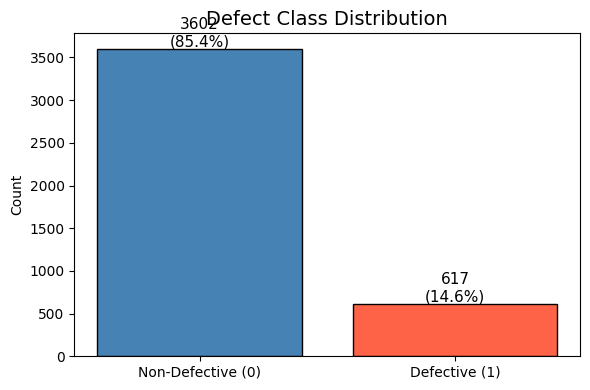

Defect
0    3602
1     617
Name: count, dtype: int64

Class Imbalance Ratio = 5.8:1  (Good : Defective)
=> SMOTE will be applied inside CV folds to balance the training set


In [ ]:
counts = df['Defect'].value_counts()
total  = len(df)

plt.figure(figsize=(6, 4))
bars = plt.bar(['Non-Defective (0)', 'Defective (1)'],
               counts.values, color=['steelblue', 'tomato'], edgecolor='black')
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 30,
             f'{int(h)}\n({h/total*100:.1f}%)', ha='center', fontsize=11)

plt.title('Defect Class Distribution', fontsize=14)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(counts)
print(f'\nClass Imbalance Ratio = {counts[0]/counts[1]:.1f}:1  (Good : Defective)')
print('=> SMOTE will be applied inside CV folds to balance the training set')

###  Tool Type Analysis

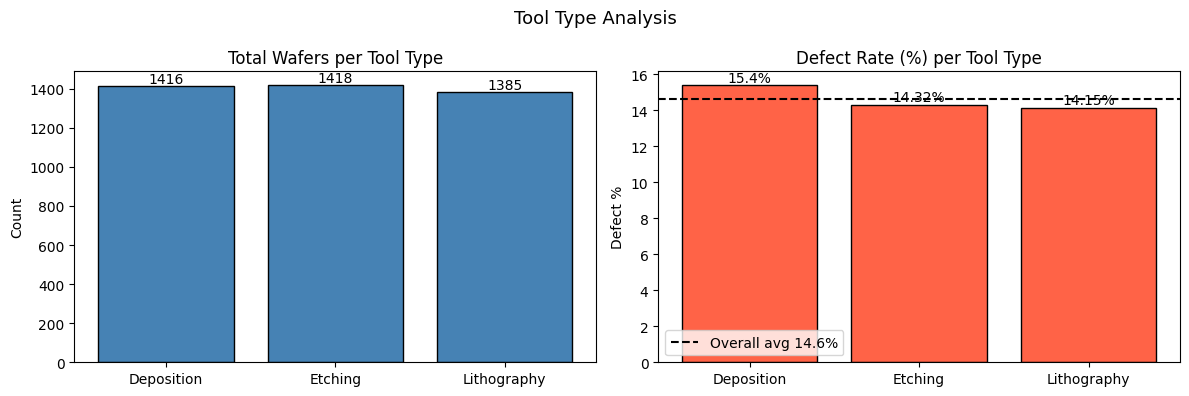

             Total_Wafers  Defective_Count  Defect_Rate_%
Tool_Type                                                
Deposition           1416              218          15.40
Etching              1418              203          14.32
Lithography          1385              196          14.15


In [ ]:
summary = df.groupby('Tool_Type')['Defect'].agg(['count','sum'])
summary.columns = ['Total_Wafers', 'Defective_Count']
summary['Defect_Rate_%'] = (summary['Defective_Count'] / summary['Total_Wafers'] * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(summary.index, summary['Total_Wafers'], color='steelblue', edgecolor='black')
axes[0].set_title('Total Wafers per Tool Type')
axes[0].set_ylabel('Count')
for i, (idx, row) in enumerate(summary.iterrows()):
    axes[0].text(i, row['Total_Wafers'] + 15, str(int(row['Total_Wafers'])), ha='center')

axes[1].bar(summary.index, summary['Defect_Rate_%'], color='tomato', edgecolor='black')
axes[1].set_title('Defect Rate (%) per Tool Type')
axes[1].set_ylabel('Defect %')
axes[1].axhline(df['Defect'].mean()*100, color='black', linestyle='--',
                label=f'Overall avg {df["Defect"].mean()*100:.1f}%')
axes[1].legend()
for i, (idx, row) in enumerate(summary.iterrows()):
    axes[1].text(i, row['Defect_Rate_%'] + 0.2, f"{row['Defect_Rate_%']}%", ha='center')

plt.suptitle('Tool Type Analysis', fontsize=13)
plt.tight_layout()
plt.show()
print(summary)

###  Feature Distributions (Histograms)

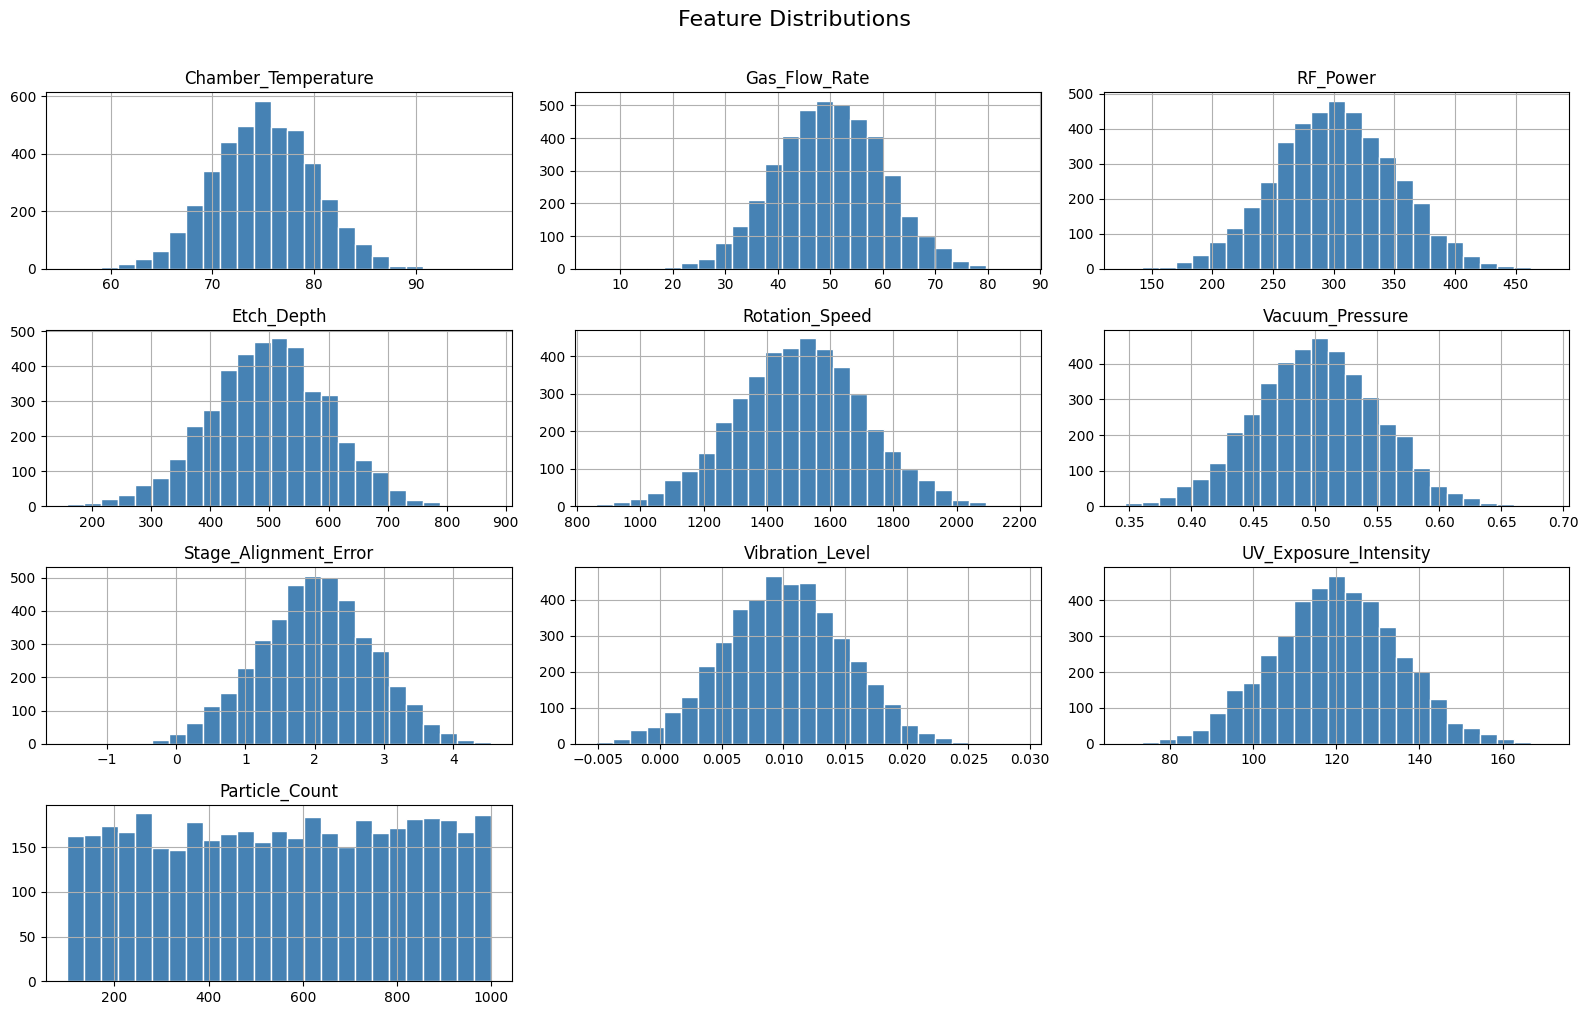

In [ ]:
num_cols = df.select_dtypes(include='number').columns.drop('Defect')

df[num_cols].hist(figsize=(16, 10), bins=25, color='steelblue', edgecolor='white')
plt.suptitle('Feature Distributions', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

###  Boxplots — Spread & Outliers

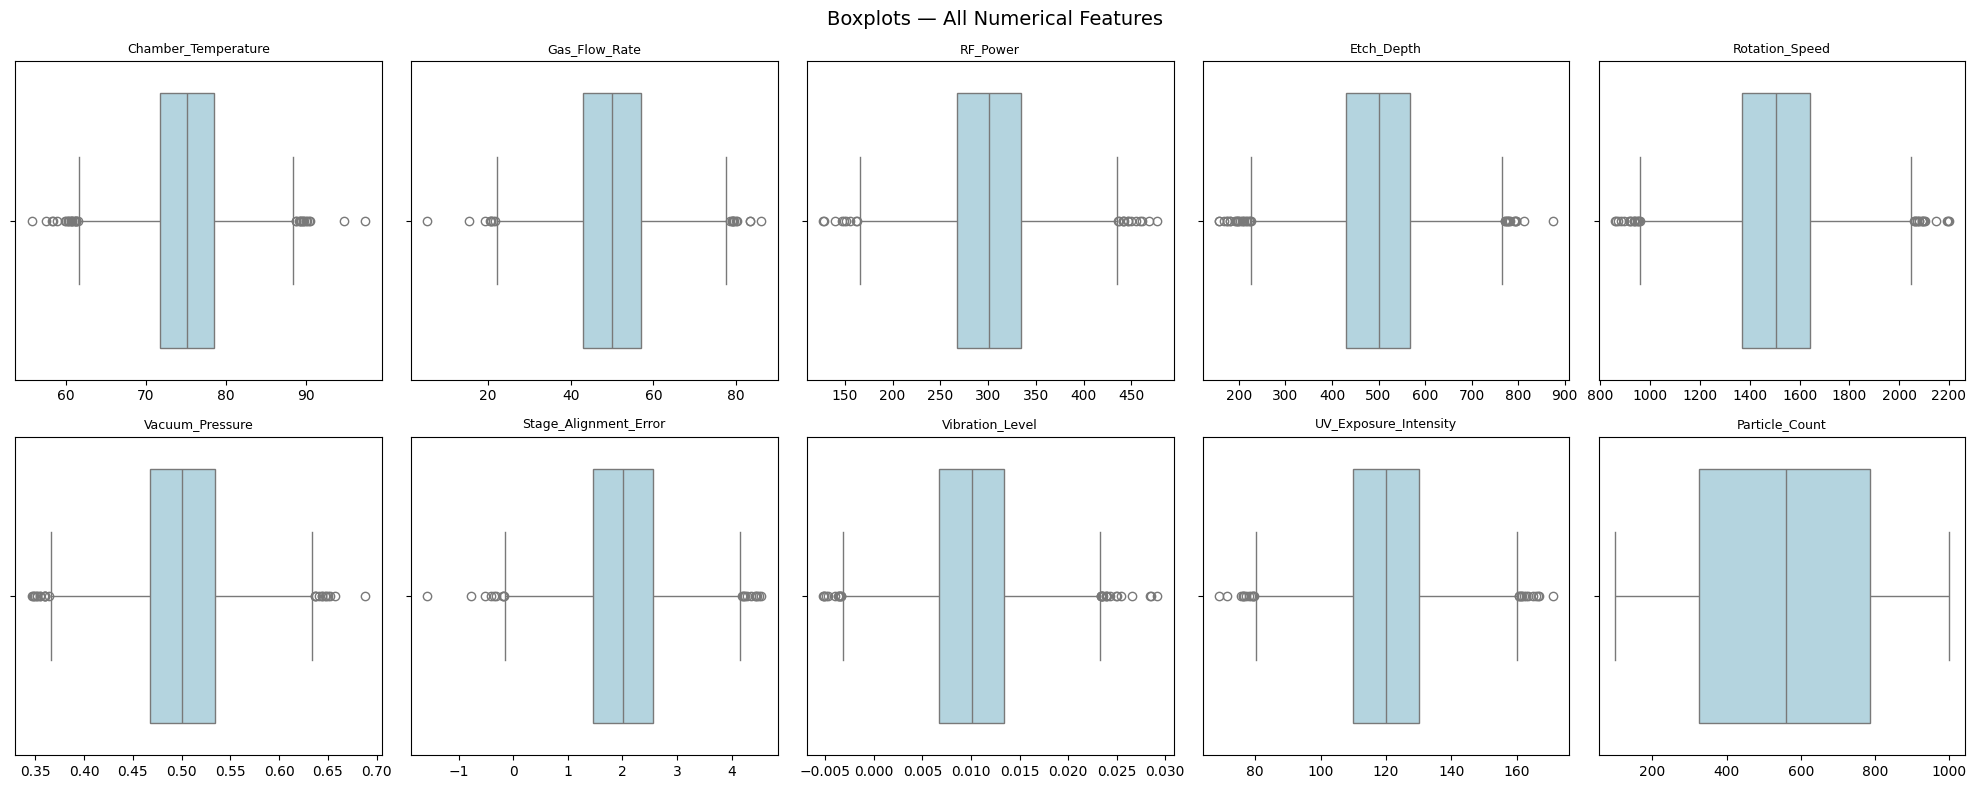

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x=col, ax=axes[i], color='lightblue')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')
plt.suptitle('Boxplots — All Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

###  Correlation Heatmap

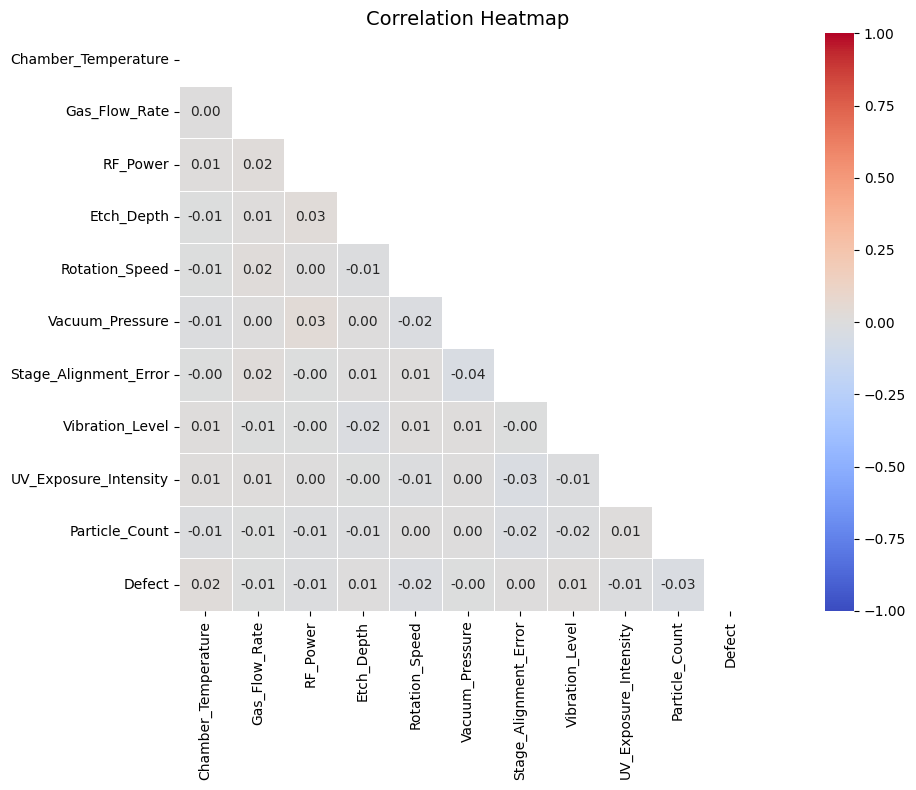

In [ ]:
plt.figure(figsize=(14, 8))
corr = df.select_dtypes(include='number').corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, square=True, vmin=-1, vmax=1)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

###  Pairplot — Key Features by Defect Class

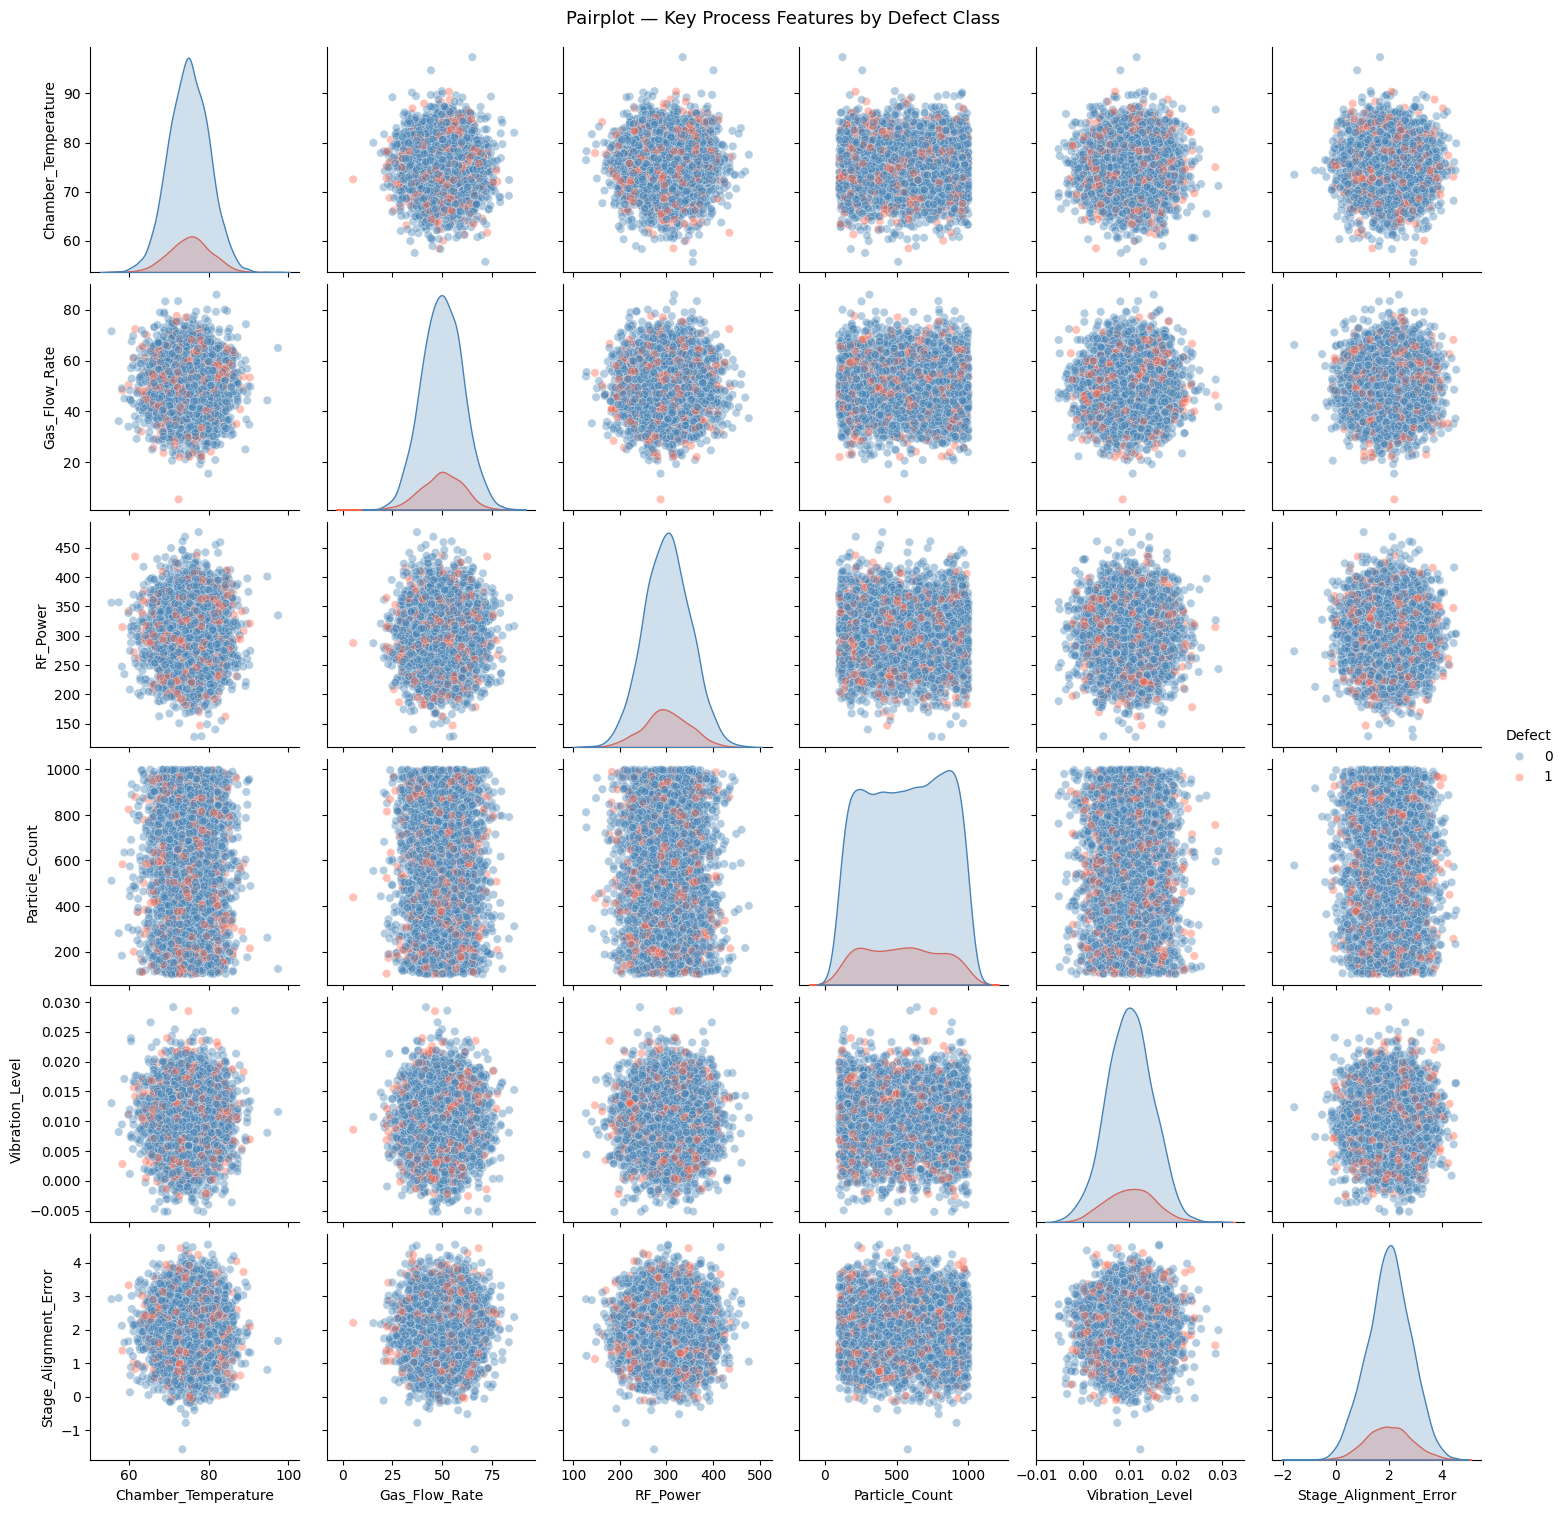

In [ ]:
pairplot_cols = ['Chamber_Temperature', 'Gas_Flow_Rate', 'RF_Power',
                 'Particle_Count', 'Vibration_Level', 'Stage_Alignment_Error', 'Defect']

pair_df = df[pairplot_cols].copy()
pair_df['Defect'] = pair_df['Defect'].astype(str)
sns.pairplot(pair_df, hue='Defect',
             palette={'0': 'steelblue', '1': 'tomato'},
             plot_kws={'alpha': 0.4}, diag_kind='kde')
plt.suptitle('Pairplot — Key Process Features by Defect Class', y=1.01, fontsize=13)
plt.show()

###  Good vs Defective — KDE Overlay per Feature

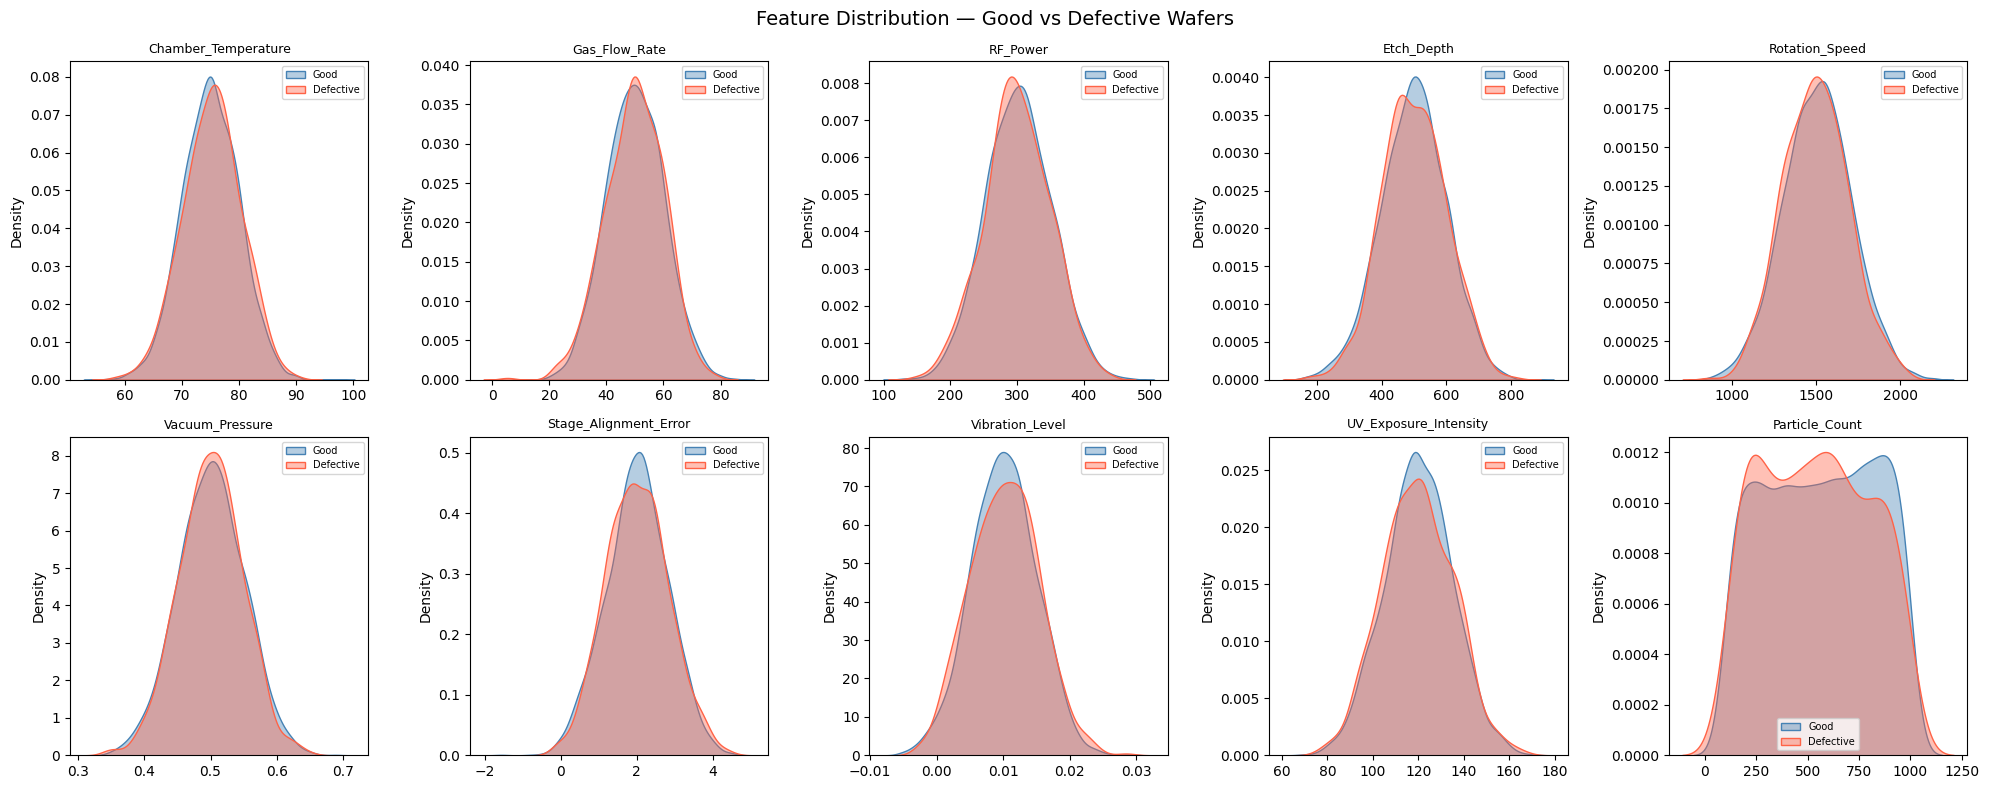

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.kdeplot(data=df[df['Defect']==0], x=col, ax=axes[i],
                label='Good', color='steelblue', fill=True, alpha=0.4)
    sns.kdeplot(data=df[df['Defect']==1], x=col, ax=axes[i],
                label='Defective', color='tomato', fill=True, alpha=0.4)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=7)
plt.suptitle('Feature Distribution — Good vs Defective Wafers', fontsize=14)
plt.tight_layout()
plt.show()

###  Sensor Readings by Defect Class (Grouped Boxplots)

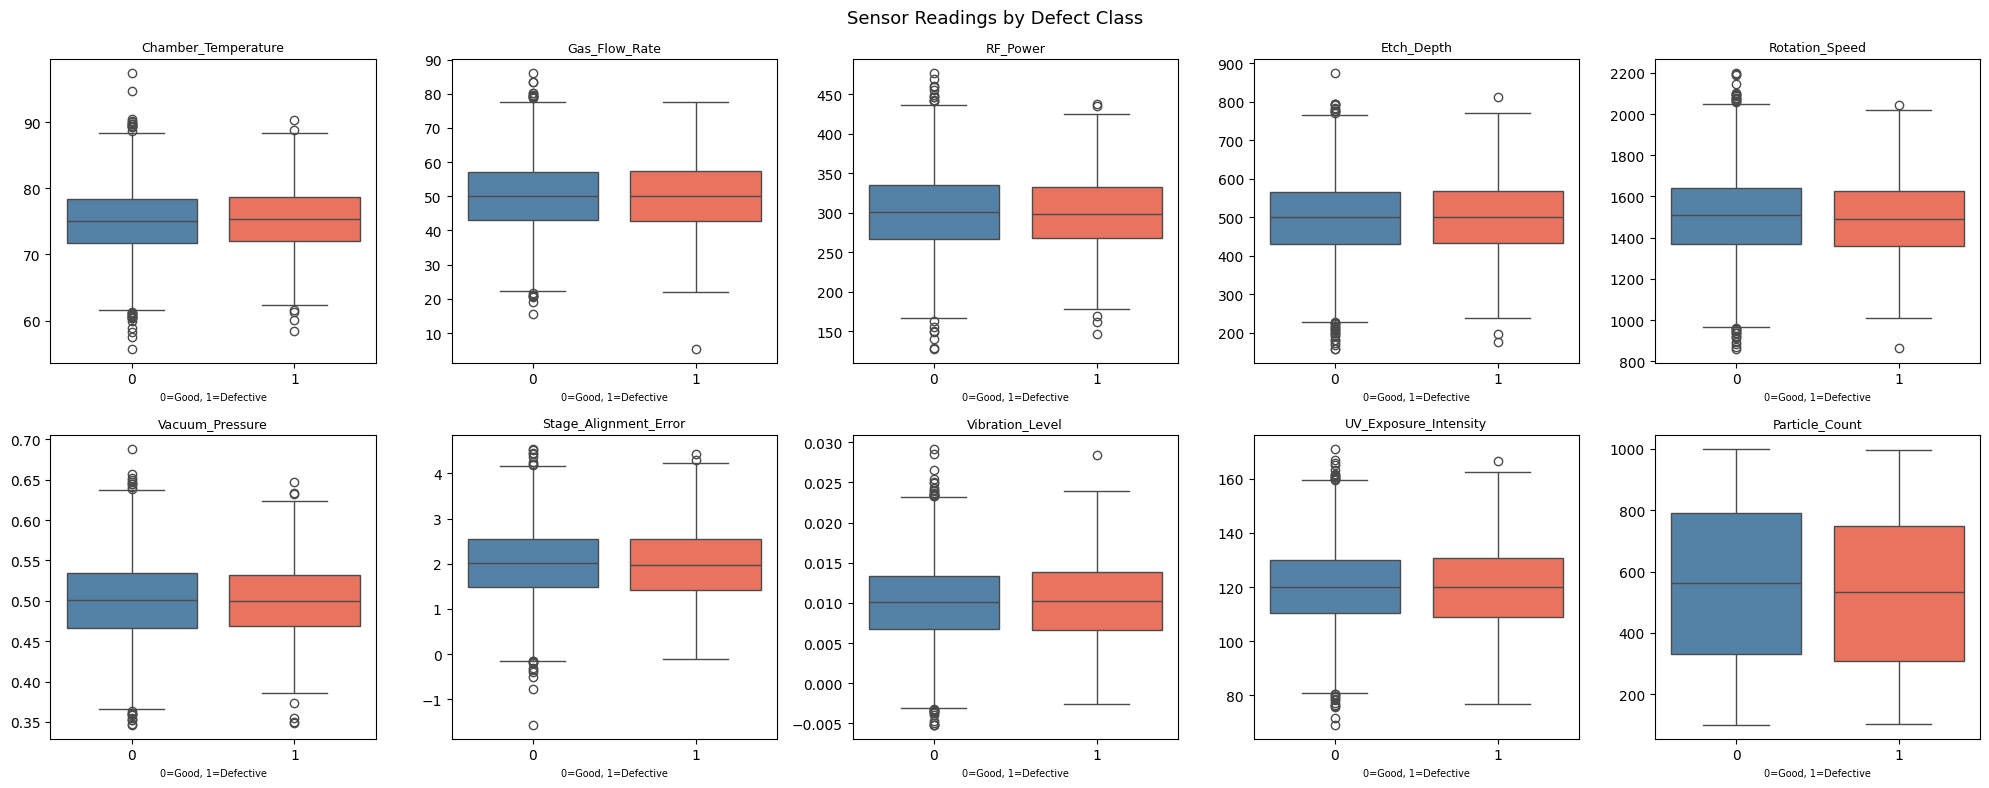

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='Defect', y=col, ax=axes[i],
                palette={'0': 'steelblue', '1': 'tomato'})
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('0=Good, 1=Defective', fontsize=7)
    axes[i].set_ylabel('')
plt.suptitle('Sensor Readings by Defect Class', fontsize=13)
plt.tight_layout()
plt.show()

##  Preprocessing

###  Drop Irrelevant Columns

In [ ]:
# Process_ID, Wafer_ID  -> unique identifiers, not predictive features
# Timestamp             -> raw datetime string
# Join_Status           -> text version of Defect column (data leakage)
df = df.drop(['Process_ID', 'Timestamp', 'Wafer_ID', 'Join_Status'], axis=1)
print('Remaining columns:', list(df.columns))

Remaining columns: ['Tool_Type', 'Chamber_Temperature', 'Gas_Flow_Rate', 'RF_Power', 'Etch_Depth', 'Rotation_Speed', 'Vacuum_Pressure', 'Stage_Alignment_Error', 'Vibration_Level', 'UV_Exposure_Intensity', 'Particle_Count', 'Defect']


###  Encode Categorical Feature — Tool Type

In [ ]:
le = LabelEncoder()
df['Tool_Type'] = le.fit_transform(df['Tool_Type'])

###  Outlier Detection & Capping (IQR Method)

In [ ]:
num_features = df.select_dtypes(include='number').columns.drop('Defect')

print('Outlier count per feature:')
for col in num_features:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    n = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f'  {col:<28} {n} outliers')

# Cap to whisker bounds — preserves all rows
for col in num_features:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

print('\nOutliers capped. Dataset shape:', df.shape)

Outlier count per feature:
  Tool_Type                    0 outliers
  Chamber_Temperature          35 outliers
  Gas_Flow_Rate                19 outliers
  RF_Power                     22 outliers
  Etch_Depth                   34 outliers
  Rotation_Speed               31 outliers
  Vacuum_Pressure              25 outliers
  Stage_Alignment_Error        20 outliers
  Vibration_Level              29 outliers
  UV_Exposure_Intensity        25 outliers
  Particle_Count               0 outliers

Outliers capped. Dataset shape: (4219, 12)


###  Define Features and Target

In [ ]:
X = df.drop('Defect', axis=1)
y = df['Defect']
print('Feature matrix :', X.shape)
print('Target         :', y.shape)
print('Features       :', list(X.columns))

Feature matrix : (4219, 11)
Target         : (4219,)
Features       : ['Tool_Type', 'Chamber_Temperature', 'Gas_Flow_Rate', 'RF_Power', 'Etch_Depth', 'Rotation_Speed', 'Vacuum_Pressure', 'Stage_Alignment_Error', 'Vibration_Level', 'UV_Exposure_Intensity', 'Particle_Count']


### Train-Test Split

In [ ]:
# stratify=y -> preserves the 14.6% defect ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print('Train size:', X_train.shape, '| Test size:', X_test.shape)

Train size: (2953, 11) | Test size: (1266, 11)


###  Feature Scaling — StandardScaler

In [ ]:
# fit_transform on train only — prevents leakage from test set
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print('Scaling done. Train shape:', X_train_sc.shape)

Scaling done. Train shape: (2953, 11)


##  SMOTE — Handling Class Imbalance

**SMOTE** creates synthetic minority (Defective) samples by interpolating between existing ones.

> **Fix applied:** SMOTE is applied **only to the raw training set** for baseline evaluation,
> and is embedded **inside** the `ImbPipeline` during GridSearchCV so it runs per-fold —
> preventing synthetic samples from leaking into validation folds.

Before SMOTE: Counter({0: 2521, 1: 432})
After  SMOTE: Counter({0: 2521, 1: 2521})


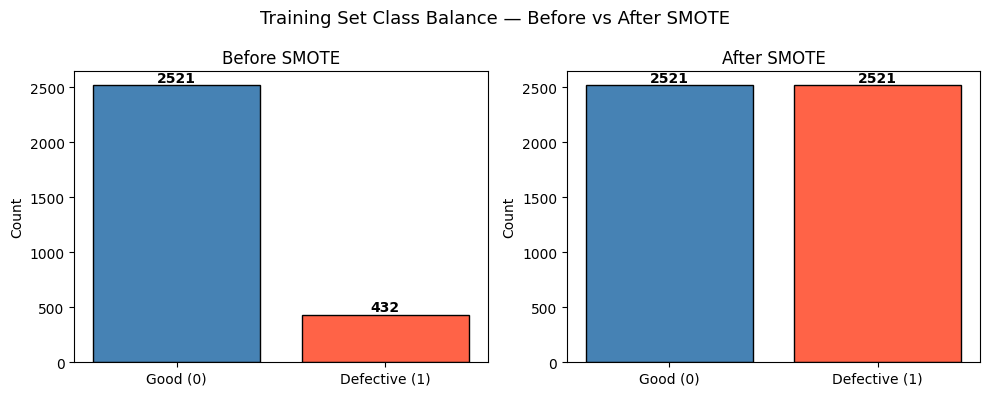

In [ ]:
print('Before SMOTE:', Counter(y_train))

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)

print('After  SMOTE:', Counter(y_train_sm))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, counts, title in zip(
    axes,
    [Counter(y_train), Counter(y_train_sm)],
    ['Before SMOTE', 'After SMOTE']
):
    bars = ax.bar(['Good (0)', 'Defective (1)'], counts.values(),
                  color=['steelblue', 'tomato'], edgecolor='black')
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('Count')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 30,
                str(int(h)), ha='center', fontweight='bold')

plt.suptitle('Training Set Class Balance — Before vs After SMOTE', fontsize=13)
plt.tight_layout()
plt.show()

##  Baseline Model Training — After SMOTE

All 7 models trained on the SMOTE-balanced training set.
Train vs Test accuracy gap is monitored to flag overfitting.

In [ ]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred       = model.predict(X_te)
    y_train_pred = model.predict(X_tr)

    train_acc = accuracy_score(y_tr, y_train_pred)
    test_acc  = accuracy_score(y_te, y_pred)
    precision = precision_score(y_te, y_pred, zero_division=0)
    recall    = recall_score(y_te, y_pred, zero_division=0)
    f1        = f1_score(y_te, y_pred, zero_division=0)

    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_te)[:, 1]
    else:
        y_prob = model.decision_function(X_te)
    auc = roc_auc_score(y_te, y_prob)

    gap = train_acc - test_acc
    overfit_flag = ' ⚠ OVERFIT' if gap > 0.10 else ''

    print(f'\n{"-"*55}')
    print(f'  {name}')
    print(f'{"-"*55}')
    print(f'  Train Accuracy : {train_acc*100:.2f}%')
    print(f'  Test  Accuracy : {test_acc*100:.2f}%  (gap={gap*100:.1f}%){overfit_flag}')
    print(f'  Precision      : {precision:.4f}')
    print(f'  Recall         : {recall:.4f}  << most important for defect detection')
    print(f'  F1 Score       : {f1:.4f}')
    print(f'  AUC-ROC        : {auc:.4f}')
    print()
    print(classification_report(y_te, y_pred,
                                target_names=['Good (0)', 'Defective (1)'],
                                zero_division=0))

    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred, display_labels=['Good', 'Defective'],
        cmap='Blues', ax=ax
    )
    ax.set_title(f'{name}')
    plt.tight_layout()
    plt.show()

    return {
        'Model'    : name,
        'Train Acc': round(train_acc*100, 2),
        'Test Acc' : round(test_acc*100,  2),
        'Gap'      : round(gap*100, 2),
        'Precision': round(precision, 4),
        'Recall'   : round(recall, 4),
        'F1'       : round(f1, 4),
        'AUC-ROC'  : round(auc, 4),
        '_model'   : model
    }

###  Logistic Regression


-------------------------------------------------------
  Logistic Regression
-------------------------------------------------------
  Train Accuracy : 55.67%
  Test  Accuracy : 51.58%  (gap=4.1%)
  Precision      : 0.1259
  Recall         : 0.3892  << most important for defect detection
  F1 Score       : 0.1902
  AUC-ROC        : 0.4669

               precision    recall  f1-score   support

     Good (0)       0.84      0.54      0.65      1081
Defective (1)       0.13      0.39      0.19       185

     accuracy                           0.52      1266
    macro avg       0.48      0.46      0.42      1266
 weighted avg       0.73      0.52      0.59      1266



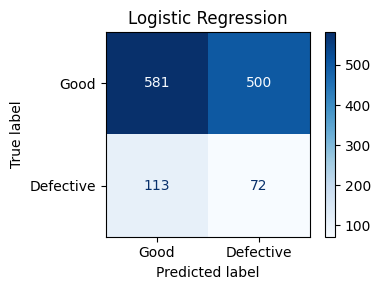

In [ ]:
results_after = []
lr_sm = LogisticRegression(max_iter=1000, random_state=42)
results_after.append(evaluate_model('Logistic Regression', lr_sm, X_train_sm, y_train_sm, X_test_sc, y_test))

###  Decision Tree

**Fix:** Default depth is bounded at `max_depth=6` with `min_samples_leaf=5`
to prevent the tree from memorising training samples.


-------------------------------------------------------
  Decision Tree
-------------------------------------------------------
  Train Accuracy : 69.12%
  Test  Accuracy : 50.95%  (gap=18.2%) ⚠ OVERFIT
  Precision      : 0.1529
  Recall         : 0.5189  << most important for defect detection
  F1 Score       : 0.2362
  AUC-ROC        : 0.5158

               precision    recall  f1-score   support

     Good (0)       0.86      0.51      0.64      1081
Defective (1)       0.15      0.52      0.24       185

     accuracy                           0.51      1266
    macro avg       0.51      0.51      0.44      1266
 weighted avg       0.76      0.51      0.58      1266



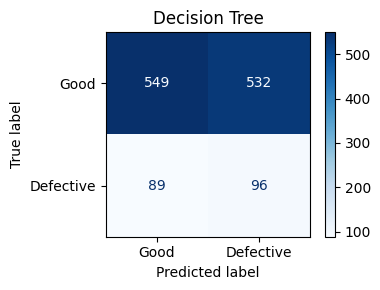

In [ ]:
dt_sm = DecisionTreeClassifier(max_depth=6, min_samples_leaf=5, random_state=42)
results_after.append(evaluate_model('Decision Tree', dt_sm, X_train_sm, y_train_sm, X_test_sc, y_test))

###  Random Forest

**Fix:** Added `max_depth=10`, `min_samples_leaf=4`, `max_features='sqrt'`
to regularise tree growth and prevent 100% train accuracy memorisation.


-------------------------------------------------------
  Random Forest
-------------------------------------------------------
  Train Accuracy : 90.10%
  Test  Accuracy : 70.46%  (gap=19.6%) ⚠ OVERFIT
  Precision      : 0.1513
  Recall         : 0.2216  << most important for defect detection
  F1 Score       : 0.1798
  AUC-ROC        : 0.4882

               precision    recall  f1-score   support

     Good (0)       0.86      0.79      0.82      1081
Defective (1)       0.15      0.22      0.18       185

     accuracy                           0.70      1266
    macro avg       0.50      0.50      0.50      1266
 weighted avg       0.75      0.70      0.73      1266



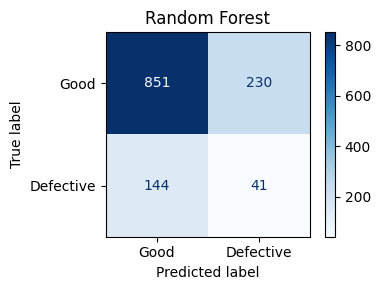

In [ ]:
rf_sm = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=4,
    max_features='sqrt',
    random_state=42
)
results_after.append(evaluate_model('Random Forest', rf_sm, X_train_sm, y_train_sm, X_test_sc, y_test))

###  KNN

**Fix:** `n_neighbors=11` (larger neighbourhood = smoother, less overfit boundary).
Uniform weights to avoid sensitivity to individual synthetic SMOTE points.


-------------------------------------------------------
  KNN
-------------------------------------------------------
  Train Accuracy : 76.60%
  Test  Accuracy : 50.00%  (gap=26.6%) ⚠ OVERFIT
  Precision      : 0.1489
  Recall         : 0.5135  << most important for defect detection
  F1 Score       : 0.2309
  AUC-ROC        : 0.4926

               precision    recall  f1-score   support

     Good (0)       0.86      0.50      0.63      1081
Defective (1)       0.15      0.51      0.23       185

     accuracy                           0.50      1266
    macro avg       0.50      0.51      0.43      1266
 weighted avg       0.75      0.50      0.57      1266



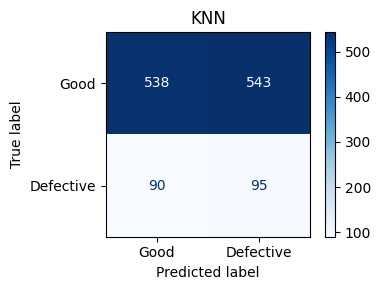

In [ ]:
knn_sm = KNeighborsClassifier(n_neighbors=11, weights='uniform')
results_after.append(evaluate_model('KNN', knn_sm, X_train_sm, y_train_sm, X_test_sc, y_test))

###  SVM


-------------------------------------------------------
  SVM
-------------------------------------------------------
  Train Accuracy : 83.60%
  Test  Accuracy : 62.56%  (gap=21.0%) ⚠ OVERFIT
  Precision      : 0.1304
  Recall         : 0.2757  << most important for defect detection
  F1 Score       : 0.1771
  AUC-ROC        : 0.4764

               precision    recall  f1-score   support

     Good (0)       0.85      0.69      0.76      1081
Defective (1)       0.13      0.28      0.18       185

     accuracy                           0.63      1266
    macro avg       0.49      0.48      0.47      1266
 weighted avg       0.74      0.63      0.67      1266



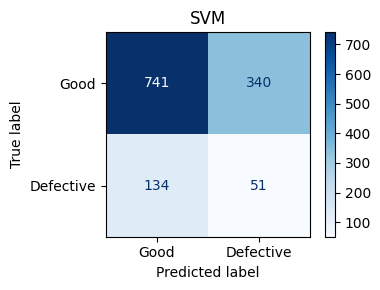

In [ ]:
svm_sm = SVC(kernel='rbf', probability=True, random_state=42)
results_after.append(evaluate_model('SVM', svm_sm, X_train_sm, y_train_sm, X_test_sc, y_test))

###  Naive Bayes


-------------------------------------------------------
  Naive Bayes
-------------------------------------------------------
  Train Accuracy : 62.63%
  Test  Accuracy : 54.66%  (gap=8.0%)
  Precision      : 0.1431
  Recall         : 0.4216  << most important for defect detection
  F1 Score       : 0.2137
  AUC-ROC        : 0.4915

               precision    recall  f1-score   support

     Good (0)       0.85      0.57      0.68      1081
Defective (1)       0.14      0.42      0.21       185

     accuracy                           0.55      1266
    macro avg       0.50      0.49      0.45      1266
 weighted avg       0.75      0.55      0.61      1266



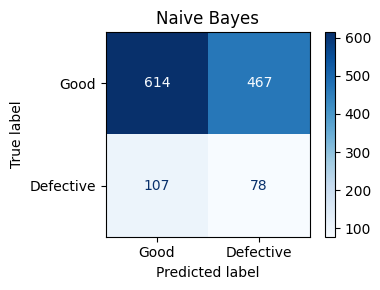

In [ ]:
nb_sm = GaussianNB()
results_after.append(evaluate_model('Naive Bayes', nb_sm, X_train_sm, y_train_sm, X_test_sc, y_test))

###  XGBoost

**Fix:** Added `subsample=0.8`, `colsample_bytree=0.8`, `reg_alpha=0.1`, `reg_lambda=1.0`
for L1/L2 regularisation and stochastic subsampling to reduce variance.


-------------------------------------------------------
  XGBoost
-------------------------------------------------------
  Train Accuracy : 94.45%
  Test  Accuracy : 72.04%  (gap=22.4%) ⚠ OVERFIT
  Precision      : 0.1435
  Recall         : 0.1838  << most important for defect detection
  F1 Score       : 0.1611
  AUC-ROC        : 0.5298

               precision    recall  f1-score   support

     Good (0)       0.85      0.81      0.83      1081
Defective (1)       0.14      0.18      0.16       185

     accuracy                           0.72      1266
    macro avg       0.50      0.50      0.50      1266
 weighted avg       0.75      0.72      0.73      1266



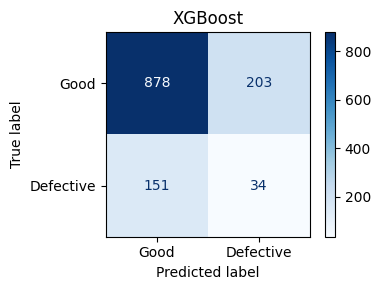

In [ ]:
xgb_sm = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='logloss',
    random_state=42
)
results_after.append(evaluate_model('XGBoost', xgb_sm, X_train_sm, y_train_sm, X_test_sc, y_test))

###  Summary — After SMOTE (Baseline)

In [ ]:
after_df = pd.DataFrame([{k: v for k, v in r.items() if k != '_model'} for r in results_after])
after_df = after_df.sort_values('Recall', ascending=False).reset_index(drop=True)
print('Model Performance — After SMOTE, Before Tuning (sorted by Recall)')
print('=' * 85)
print(after_df[['Model','Train Acc','Test Acc','Gap','Recall','F1','AUC-ROC']].to_string(index=False))
print()
print('Note: Gap = Train Acc - Test Acc. Values > 10% indicate overfitting.')

Model Performance — After SMOTE, Before Tuning (sorted by Recall)
              Model  Train Acc  Test Acc   Gap  Recall     F1  AUC-ROC
      Decision Tree      69.12     50.95 18.17  0.5189 0.2362   0.5158
                KNN      76.60     50.00 26.60  0.5135 0.2309   0.4926
        Naive Bayes      62.63     54.66  7.97  0.4216 0.2137   0.4915
Logistic Regression      55.67     51.58  4.09  0.3892 0.1902   0.4669
                SVM      83.60     62.56 21.04  0.2757 0.1771   0.4764
      Random Forest      90.10     70.46 19.64  0.2216 0.1798   0.4882
            XGBoost      94.45     72.04 22.41  0.1838 0.1611   0.5298

Note: Gap = Train Acc - Test Acc. Values > 10% indicate overfitting.


###  ROC Curves — After SMOTE

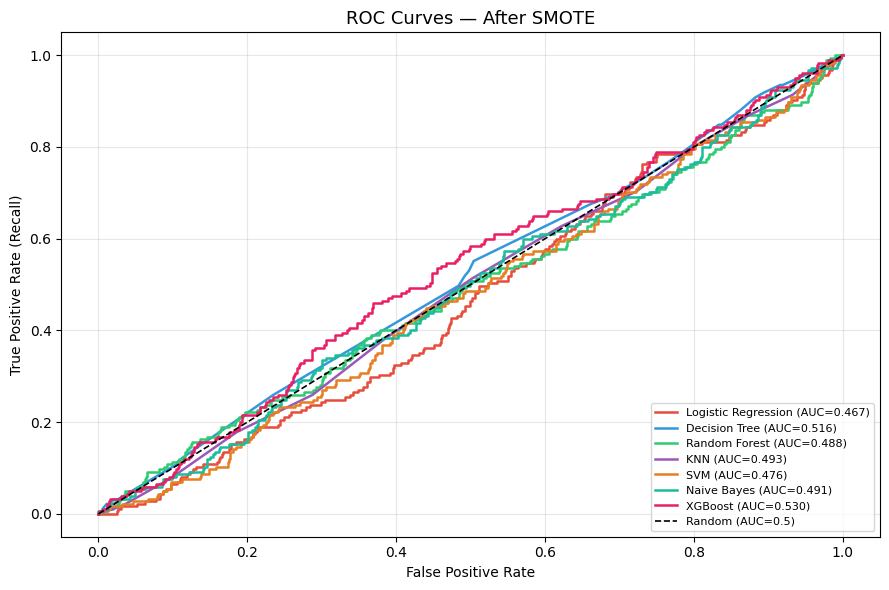

In [ ]:
plt.figure(figsize=(9, 6))
colors = ['#e74c3c','#3498db','#2ecc71','#9b59b6','#e67e22','#1abc9c','#e91e63']

for r, col in zip(results_after, colors):
    model = r['_model']
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test_sc)[:, 1]
    else:
        y_prob = model.decision_function(X_test_sc)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, color=col, lw=1.8,
             label=f"{r['Model']} (AUC={r['AUC-ROC']:.3f})")

plt.plot([0,1],[0,1],'k--', lw=1.2, label='Random (AUC=0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves — After SMOTE', fontsize=13)
plt.legend(loc='lower right', fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

###  All Models Selected for Tuning

In [ ]:
after_ranked = pd.DataFrame([{k: v for k, v in r.items() if k != '_model'} for r in results_after])
after_ranked = after_ranked.sort_values('F1', ascending=False).reset_index(drop=True)
print('All Models after SMOTE (sorted by F1) — all selected for tuning:')
print(after_ranked[['Model','Train Acc','Test Acc','Gap','Recall','F1','AUC-ROC']].to_string(index=False))

All Models after SMOTE (sorted by F1) — all selected for tuning:
              Model  Train Acc  Test Acc   Gap  Recall     F1  AUC-ROC
      Decision Tree      69.12     50.95 18.17  0.5189 0.2362   0.5158
                KNN      76.60     50.00 26.60  0.5135 0.2309   0.4926
        Naive Bayes      62.63     54.66  7.97  0.4216 0.2137   0.4915
Logistic Regression      55.67     51.58  4.09  0.3892 0.1902   0.4669
      Random Forest      90.10     70.46 19.64  0.2216 0.1798   0.4882
                SVM      83.60     62.56 21.04  0.2757 0.1771   0.4764
            XGBoost      94.45     72.04 22.41  0.1838 0.1611   0.5298


##  Hyperparameter Tuning — All Models

**Key fix:** `ImbPipeline` embeds SMOTE **inside** each CV fold.
GridSearchCV with 5-fold Stratified CV, scored on **F1**.

Tuning Decision Tree (SMOTE inside CV folds)...
  Best Params : {'clf__criterion': 'entropy', 'clf__max_depth': 8, 'clf__min_samples_leaf': 4, 'clf__min_samples_split': 20}
  Best CV F1  : 0.2422
  Train Acc=67.15%  Test Acc=61.06%  Gap=6.1%
  Recall=0.3892  F1=0.2261  AUC=0.5268

               precision    recall  f1-score   support

     Good (0)       0.86      0.65      0.74      1081
Defective (1)       0.16      0.39      0.23       185

     accuracy                           0.61      1266
    macro avg       0.51      0.52      0.48      1266
 weighted avg       0.76      0.61      0.66      1266



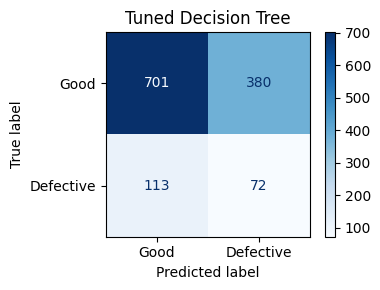

Tuning KNN (SMOTE inside CV folds)...
  Best Params : {'clf__metric': 'euclidean', 'clf__n_neighbors': 21, 'clf__weights': 'uniform'}
  Best CV F1  : 0.2589
  Train Acc=55.13%  Test Acc=44.55%  Gap=10.6% ⚠ OVERFIT
  Recall=0.5459  F1=0.2235  AUC=0.4773

               precision    recall  f1-score   support

     Good (0)       0.85      0.43      0.57      1081
Defective (1)       0.14      0.55      0.22       185

     accuracy                           0.45      1266
    macro avg       0.49      0.49      0.40      1266
 weighted avg       0.74      0.45      0.52      1266



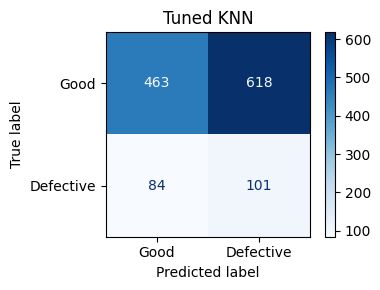

Tuning Naive Bayes (SMOTE inside CV folds)...
  Best Params : {'clf__var_smoothing': 1e-09}
  Best CV F1  : 0.2437
  Train Acc=56.32%  Test Acc=54.66%  Gap=1.7%
  Recall=0.4216  F1=0.2137  AUC=0.4915

               precision    recall  f1-score   support

     Good (0)       0.85      0.57      0.68      1081
Defective (1)       0.14      0.42      0.21       185

     accuracy                           0.55      1266
    macro avg       0.50      0.49      0.45      1266
 weighted avg       0.75      0.55      0.61      1266



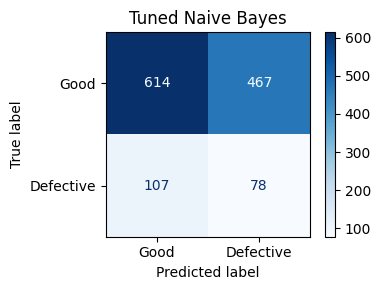

Tuning Logistic Regression (SMOTE inside CV folds)...
  Best Params : {'clf__C': 0.1, 'clf__max_iter': 500, 'clf__solver': 'lbfgs'}
  Best CV F1  : 0.2566
  Train Acc=54.35%  Test Acc=51.58%  Gap=2.8%
  Recall=0.3892  F1=0.1902  AUC=0.4669

               precision    recall  f1-score   support

     Good (0)       0.84      0.54      0.65      1081
Defective (1)       0.13      0.39      0.19       185

     accuracy                           0.52      1266
    macro avg       0.48      0.46      0.42      1266
 weighted avg       0.73      0.52      0.59      1266



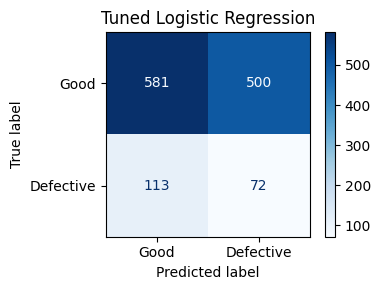

Tuning Random Forest (SMOTE inside CV folds)...
  Best Params : {'clf__max_depth': 6, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 2, 'clf__n_estimators': 200}
  Best CV F1  : 0.2400
  Train Acc=71.52%  Test Acc=62.72%  Gap=8.8%
  Recall=0.3297  F1=0.2054  AUC=0.4775

               precision    recall  f1-score   support

     Good (0)       0.86      0.68      0.76      1081
Defective (1)       0.15      0.33      0.21       185

     accuracy                           0.63      1266
    macro avg       0.50      0.50      0.48      1266
 weighted avg       0.75      0.63      0.68      1266



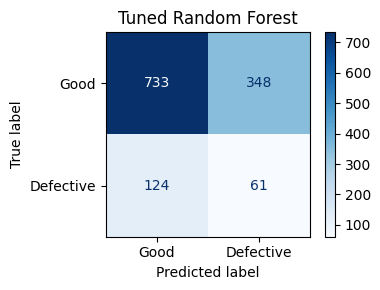

Tuning SVM (SMOTE inside CV folds)...
  Best Params : {'clf__C': 1, 'clf__gamma': 'auto'}
  Best CV F1  : 0.2364
  Train Acc=74.97%  Test Acc=61.30%  Gap=13.7% ⚠ OVERFIT
  Recall=0.2811  F1=0.1751  AUC=0.4772

               precision    recall  f1-score   support

     Good (0)       0.84      0.67      0.75      1081
Defective (1)       0.13      0.28      0.18       185

     accuracy                           0.61      1266
    macro avg       0.49      0.48      0.46      1266
 weighted avg       0.74      0.61      0.66      1266



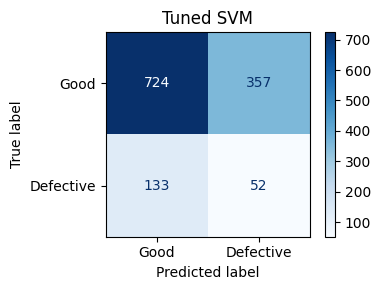

Tuning XGBoost (SMOTE inside CV folds)...
  Best Params : {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 100, 'clf__reg_alpha': 0, 'clf__reg_lambda': 1.0, 'clf__subsample': 1.0}
  Best CV F1  : 0.2346
  Train Acc=76.43%  Test Acc=66.67%  Gap=9.8%
  Recall=0.2541  F1=0.1822  AUC=0.4857

               precision    recall  f1-score   support

     Good (0)       0.85      0.74      0.79      1081
Defective (1)       0.14      0.25      0.18       185

     accuracy                           0.67      1266
    macro avg       0.50      0.50      0.49      1266
 weighted avg       0.75      0.67      0.70      1266



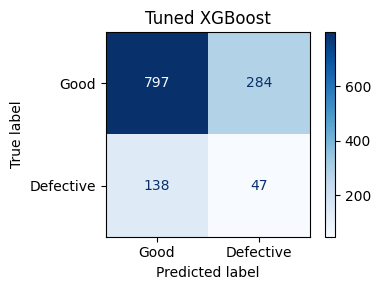

In [ ]:
# Parameter grids — max_depth=None removed from Decision Tree grid
# KNN minimum n_neighbors raised to 5 to avoid overfitting to noise
PARAM_GRIDS = {
    'Random Forest': (
        RandomForestClassifier(random_state=42),
        {
            'clf__n_estimators': [100, 200],
            'clf__max_depth': [6, 10, 15],           # no None — prevents unbounded growth
            'clf__min_samples_leaf': [2, 4, 8],      # regularisation floor
            'clf__max_features': ['sqrt', 'log2']    # feature subsampling
        }
    ),
    'XGBoost': (
        XGBClassifier(eval_metric='logloss', random_state=42),
        {
            'clf__n_estimators': [100, 200],
            'clf__max_depth': [3, 4, 6],
            'clf__learning_rate': [0.05, 0.1],
            'clf__subsample': [0.7, 0.8, 1.0],
            'clf__colsample_bytree': [0.7, 0.8, 1.0],
            'clf__reg_alpha': [0, 0.1, 0.5],         # L1
            'clf__reg_lambda': [0.5, 1.0, 2.0]       # L2
        }
    ),
    'Decision Tree': (
        DecisionTreeClassifier(random_state=42),
        {
            'clf__max_depth': [4, 6, 8, 10],          # max_depth=None removed
            'clf__min_samples_split': [5, 10, 20],    # raised floor
            'clf__min_samples_leaf': [2, 4, 8],       # added leaf size regularisation
            'clf__criterion': ['gini', 'entropy']
        }
    ),
    'KNN': (
        KNeighborsClassifier(),
        {
            'clf__n_neighbors': [7, 11, 15, 21],      # minimum raised from 3 to 7
            'clf__weights': ['uniform', 'distance'],
            'clf__metric': ['euclidean', 'manhattan']
        }
    ),
    'SVM': (
        SVC(kernel='rbf', probability=True, random_state=42),
        {
            'clf__C': [0.1, 1, 10],
            'clf__gamma': ['scale', 'auto']
        }
    ),
    'Logistic Regression': (
        LogisticRegression(random_state=42),
        {
            'clf__C': [0.01, 0.1, 1, 10],
            'clf__solver': ['lbfgs', 'liblinear'],
            'clf__max_iter': [500, 1000]
        }
    ),
    'Naive Bayes': (
        GaussianNB(),
        {'clf__var_smoothing': [1e-9, 1e-8, 1e-7]}
    )
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tuned_results = []
tuned_models  = {}

for _, row in after_ranked.iterrows():
    mname = row['Model']
    base_clf, pgrid = PARAM_GRIDS[mname]

    # ImbPipeline: SMOTE runs inside each CV fold — no leakage
    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('clf',   base_clf)
    ])

    print(f'Tuning {mname} (SMOTE inside CV folds)...')
    gs = GridSearchCV(pipe, pgrid, cv=skf, scoring='f1', n_jobs=-1, verbose=0)
    gs.fit(X_train_sc, y_train)   # raw scaled training data — no pre-applied SMOTE

    print(f'  Best Params : {gs.best_params_}')
    print(f'  Best CV F1  : {gs.best_score_:.4f}')

    best_pipe = gs.best_estimator_
    y_pred    = best_pipe.predict(X_test_sc)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, best_pipe.predict_proba(X_test_sc)[:,1])

    # Train accuracy on raw (non-SMOTE) training data — honest gap measure
    y_train_pred = best_pipe.predict(X_train_sc)
    train_acc    = accuracy_score(y_train, y_train_pred)
    gap          = train_acc - acc
    overfit_flag = ' ⚠ OVERFIT' if gap > 0.10 else ''

    print(f'  Train Acc={train_acc*100:.2f}%  Test Acc={acc*100:.2f}%  Gap={gap*100:.1f}%{overfit_flag}')
    print(f'  Recall={rec:.4f}  F1={f1:.4f}  AUC={auc:.4f}')
    print()
    print(classification_report(y_test, y_pred, target_names=['Good (0)','Defective (1)'], zero_division=0))

    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred,
        display_labels=['Good','Defective'], cmap='Blues', ax=ax)
    ax.set_title(f'Tuned {mname}')
    plt.tight_layout(); plt.show()

    tuned_results.append({
        'Model'    : f'{mname} (Tuned)',
        'Train Acc': round(train_acc*100, 2),
        'Test Acc' : round(acc*100, 2),
        'Gap'      : round(gap*100, 2),
        'Precision': round(prec, 4),
        'Recall'   : round(rec, 4),
        'F1'       : round(f1, 4),
        'AUC-ROC'  : round(auc, 4)
    })
    tuned_models[mname] = best_pipe

##  Results — After SMOTE & After Tuning

In [ ]:
after_clean = pd.DataFrame([{k: v for k, v in r.items() if k != '_model'} for r in results_after])
after_clean = after_clean.sort_values('F1', ascending=False).reset_index(drop=True)

tuned_clean = pd.DataFrame(tuned_results)
tuned_clean = tuned_clean.sort_values('F1', ascending=False).reset_index(drop=True)

print('All Models — After SMOTE')
print('=' * 80)
print(after_clean[['Model','Train Acc','Test Acc','Gap','Recall','F1','AUC-ROC']].to_string(index=False))

print()
print('All Models — After Hyperparameter Tuning')
print('=' * 80)
print(tuned_clean[['Model','Train Acc','Test Acc','Gap','Recall','F1','AUC-ROC']].to_string(index=False))

All Models — After SMOTE
              Model  Train Acc  Test Acc   Gap  Recall     F1  AUC-ROC
      Decision Tree      69.12     50.95 18.17  0.5189 0.2362   0.5158
                KNN      76.60     50.00 26.60  0.5135 0.2309   0.4926
        Naive Bayes      62.63     54.66  7.97  0.4216 0.2137   0.4915
Logistic Regression      55.67     51.58  4.09  0.3892 0.1902   0.4669
      Random Forest      90.10     70.46 19.64  0.2216 0.1798   0.4882
                SVM      83.60     62.56 21.04  0.2757 0.1771   0.4764
            XGBoost      94.45     72.04 22.41  0.1838 0.1611   0.5298

All Models — After Hyperparameter Tuning
                      Model  Train Acc  Test Acc   Gap  Recall     F1  AUC-ROC
      Decision Tree (Tuned)      67.15     61.06  6.09  0.3892 0.2261   0.5268
                KNN (Tuned)      55.13     44.55 10.58  0.5459 0.2235   0.4773
        Naive Bayes (Tuned)      56.32     54.66  1.66  0.4216 0.2137   0.4915
      Random Forest (Tuned)      71.52     62.72 

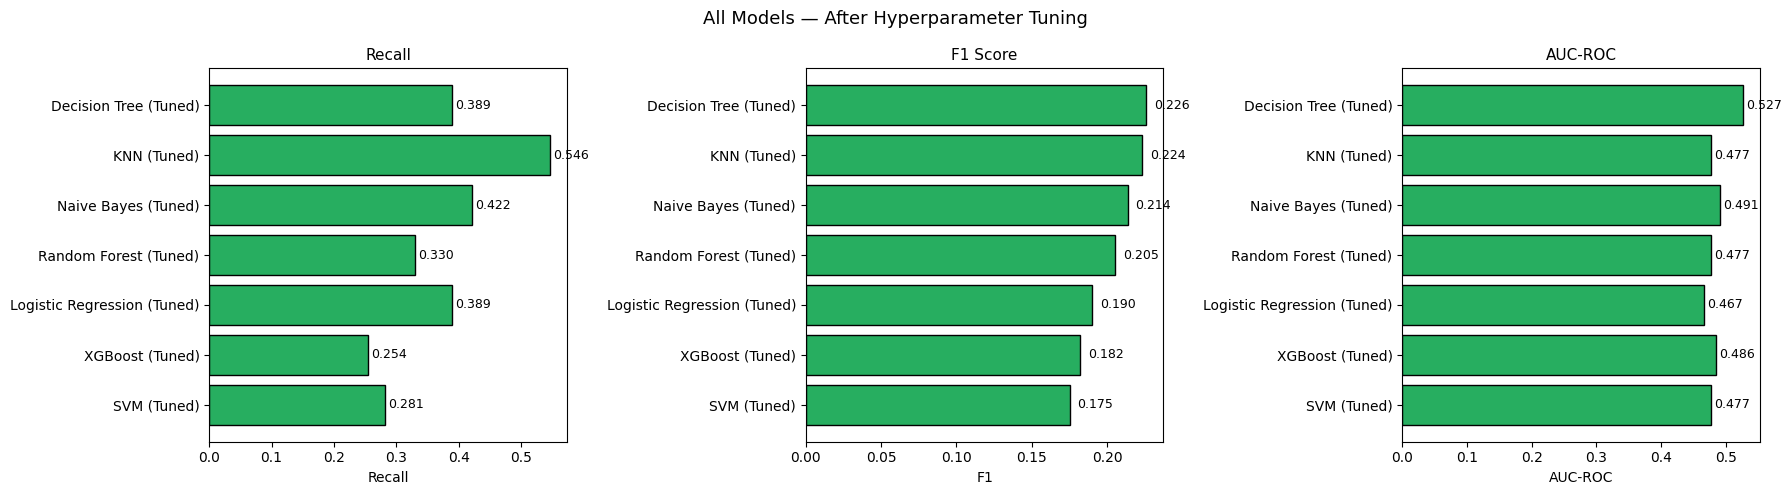

In [ ]:
tuned_df = pd.DataFrame(tuned_results).sort_values('F1', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric, title in zip(axes, ['Recall', 'F1', 'AUC-ROC'],
                              ['Recall', 'F1 Score', 'AUC-ROC']):
    bars = ax.barh(tuned_df['Model'][::-1], tuned_df[metric][::-1],
                   color='#27ae60', edgecolor='black')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(metric)
    for bar in bars:
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.3f}', va='center', fontsize=9)

plt.suptitle('All Models — After Hyperparameter Tuning', fontsize=13)
plt.tight_layout()
plt.show()

##  Save Best Model

In [ ]:
import joblib

best_model = tuned_models['Decision Tree']

joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')
joblib.dump(list(X.columns), 'features.pkl')

print(f'\nBest Model: {best_model_name}')


Best Model: Decision Tree (Tuned)
